# Data Cleaning and Preprocessing
## Customer Personality Analysis Dataset

**Module 03 — Machine Learning Internship (AI Lab 99)**

This notebook performs the full preprocessing workflow: loading, inspecting,
cleaning, validating, and exporting the Customer Personality Analysis dataset
so it is ready for Exploratory Data Analysis (EDA) and Machine Learning.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
%matplotlib inline

BASE = Path(".")
RAW = BASE / "01_Raw_Data"
QUALITY = BASE / "02_Data_Quality_Assessment"
CLEANED = BASE / "03_Cleaned_Data"
VIZ = BASE / "04_Visualizations"
REPORTS = BASE / "05_Reports"
for folder in [RAW, QUALITY, CLEANED, VIZ, REPORTS]:
    folder.mkdir(exist_ok=True)

CURRENT_YEAR = 2026
NUMERIC_SPEND_COLS = ["Income", "MntWines", "MntFruits", "MntMeatProducts",
                       "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

## Activity 1 — Load and Inspect the Dataset

In [2]:
df = pd.read_csv(RAW / "marketing_campaign.csv", sep=None, engine="python", encoding="utf-8")
print("Shape:", df.shape)
df.head(10)

Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,20,1,0,0,0,0,0,3,11,0


In [3]:
df.tail(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2230,7004,1984,Graduation,Single,11012.0,1,0,16-03-2013,82,24,...,9,1,0,0,0,0,0,3,11,0
2231,9817,1970,Master,Single,44802.0,0,0,21-08-2012,71,853,...,8,0,0,0,0,0,0,3,11,0
2232,8080,1986,Graduation,Single,26816.0,0,0,17-08-2012,50,5,...,4,0,0,0,0,0,0,3,11,0
2233,9432,1977,Graduation,Together,666666.0,1,0,02-06-2013,23,9,...,6,0,0,0,0,0,0,3,11,0
2234,8372,1974,Graduation,Married,34421.0,1,0,01-07-2013,81,3,...,7,0,0,0,0,0,0,3,11,0
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,...,7,0,0,0,0,0,0,3,11,1


In [4]:
print(list(df.columns))
df.dtypes

['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2240.0,NaN,NaN,NaN,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,NaN,NaN,NaN,1968.805804,11.984069,1893.0,1959.0,1970.0,1977.0,1996.0
Education,2240,5,Graduation,1127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2240,8,Married,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,2216.0,NaN,NaN,NaN,52247.251354,25173.076661,1730.0,35303.0,51381.5,68522.0,666666.0
Kidhome,2240.0,NaN,NaN,NaN,0.444196,0.538398,0.0,0.0,0.0,1.0,2.0
Teenhome,2240.0,NaN,NaN,NaN,0.50625,0.544538,0.0,0.0,0.0,1.0,2.0
Dt_Customer,2240,663,31-08-2012,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recency,2240.0,NaN,NaN,NaN,49.109375,28.962453,0.0,24.0,49.0,74.0,99.0
MntWines,2240.0,NaN,NaN,NaN,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0


## Activity 2 — Identify Data Quality Issues

Data Quality Assessment table covering missing values, duplicates, incorrect
data types, invalid dates, inconsistent categories, unrealistic values and
outliers.

In [6]:
issues = []
def add(issue, column, description, severity):
    issues.append({"Issue": issue, "Column": column, "Description": description, "Severity": severity})

missing_income = int(df["Income"].isna().sum())
add("Missing values", "Income", f"{missing_income} missing income values "
    f"({round(missing_income/len(df)*100,2)}%).", "Medium")

dup_rows = int(df.duplicated().sum())
dup_ids = int(df["ID"].duplicated().sum())
add("Duplicate records", "All columns", f"{dup_rows} fully duplicated rows.", "Medium")
add("Duplicate IDs", "ID", f"{dup_ids} duplicate customer IDs.", "High")

add("Incorrect data type", "Dt_Customer", "Stored as text instead of datetime.", "Medium")

test_dates = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y", errors="coerce")
invalid_dates = int(test_dates.isna().sum())
add("Invalid dates", "Dt_Customer", f"{invalid_dates} dates could not be parsed.", "Medium")

unexpected_marital = [v for v in ["Alone", "Absurd", "YOLO"] if v in df["Marital_Status"].unique()]
add("Inconsistent categories", "Marital_Status",
    f"Unexpected values: {', '.join(unexpected_marital)}.", "Low")

add("Unclear category label", "Education", "'2n Cycle' is an ambiguous label.", "Low")

ages_tmp = CURRENT_YEAR - df["Year_Birth"]
add("Unrealistic values", "Year_Birth", f"{int((ages_tmp > 100).sum())} customers appear older than 100 years.", "High")

negative_income = int((df["Income"] < 0).sum())
add("Unrealistic values", "Income", f"{negative_income} negative income values.", "High")

for col in NUMERIC_SPEND_COLS:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = int(((df[col] < lower) | (df[col] > upper)).sum())
    add("Outliers (IQR method)", col, f"{n_out} values outside [{round(lower,1)}, {round(upper,1)}].", "Medium")

for col in ["Z_CostContact", "Z_Revenue"]:
    if df[col].nunique() == 1:
        add("Constant variable", col, "Column has only one unique value.", "Low")

quality_df = pd.DataFrame(issues)
quality_df.to_excel(QUALITY / "02_data_quality_assessment.xlsx", index=False)
quality_df

,Issue,Column,Description,Severity
0,Missing values,Income,24 missing income values (1.07%).,Medium
1,Duplicate records,All columns,0 fully duplicated rows.,Medium
2,Duplicate IDs,ID,0 duplicate customer IDs.,High
3,Incorrect data type,Dt_Customer,Stored as text instead of datetime.,Medium
4,Invalid dates,Dt_Customer,0 dates could not be parsed.,Medium
5,Inconsistent categories,Marital_Status,"Unexpected values: Alone, Absurd, YOLO.",Low
6,Unclear category label,Education,'2n Cycle' is an ambiguous label.,Low
7,Unrealistic values,Year_Birth,3 customers appear older than 100 years.,High
8,Unrealistic values,Income,0 negative income values.,High
9,Outliers (IQR method),Income,"8 values outside [-14525.5, 118350.5].",Medium


## Activity 3 — Handle Missing Values

**Method chosen: Median Imputation for `Income`.**
Income is right-skewed (a small number of very high earners), so the median
is a more robust, representative measure of central tendency than the mean,
which would be pulled upward by outliers. With missingness under 2% of
records, dropping rows was not necessary.

In [7]:
missing_before = df.isna().sum()
missing_report = pd.DataFrame({"Variable": df.columns, "Missing Values": missing_before.values,
                                "Percentage": (missing_before.values/len(df)*100).round(2)})
missing_report.to_excel(QUALITY / "03_missing_values_before.xlsx", index=False)
missing_report[missing_report["Missing Values"] > 0]

,Variable,Missing Values,Percentage
4,Income,24,1.07


In [8]:
median_income = df["Income"].median()
n_missing = int(df["Income"].isna().sum())
df["Income"] = df["Income"].fillna(median_income)
print(f"Missing Income values imputed: {n_missing} -> filled with median = {median_income}")

Missing Income values imputed: 24 -> filled with median = 51381.5


## Activity 4 — Remove Duplicate Records

In [9]:
before = len(df)
dup_rows = int(df.duplicated().sum())
dup_ids = int(df["ID"].duplicated().sum())

df = df.drop_duplicates()
df = df.drop_duplicates(subset="ID", keep="first").reset_index(drop=True)

after = len(df)
removed = before - after
pd.DataFrame({"Before": [before], "After": [after], "Removed": [removed]})

,Before,After,Removed
0,2240,2240,0


## Activity 5 — Correct Data Types

In [10]:
old_types = df.dtypes.astype(str).to_dict()

df["ID"] = df["ID"].astype(int)
df["Year_Birth"] = df["Year_Birth"].astype(int)
df["Income"] = df["Income"].astype(float)
df["Recency"] = df["Recency"].astype(int)
df["Kidhome"] = df["Kidhome"].astype(int)
df["Teenhome"] = df["Teenhome"].astype(int)
df["Education"] = df["Education"].astype("category")
df["Marital_Status"] = df["Marital_Status"].astype("category")

binary_cols = ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Complain","Response"]
for c in binary_cols:
    df[c] = df[c].astype(int)

new_types = df.dtypes.astype(str).to_dict()
type_report = pd.DataFrame({"Variable": list(old_types.keys()),
                             "Old Type": list(old_types.values()),
                             "New Type": [new_types[c] for c in old_types.keys()]})
type_report

,Variable,Old Type,New Type
0,ID,int64,int64
1,Year_Birth,int64,int64
2,Education,str,category
3,Marital_Status,str,category
4,Income,float64,float64
5,Kidhome,int64,int64
6,Teenhome,int64,int64
7,Dt_Customer,str,str
8,Recency,int64,int64
9,MntWines,int64,int64


## Activity 6 — Convert Date Columns

In [11]:
original = df["Dt_Customer"].copy()
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y", errors="coerce")

invalid = int((original.notna() & df["Dt_Customer"].isna()).sum())
print("Invalid dates found:", invalid)
if invalid:
    df = df.dropna(subset=["Dt_Customer"]).reset_index(drop=True)

df["Enrollment_Year"] = df["Dt_Customer"].dt.year
df["Enrollment_Month"] = df["Dt_Customer"].dt.month
df["Enrollment_Day"] = df["Dt_Customer"].dt.day

print("Date range:", df["Dt_Customer"].min().date(), "to", df["Dt_Customer"].max().date())
df[["Dt_Customer", "Enrollment_Year", "Enrollment_Month", "Enrollment_Day"]].head()

Invalid dates found: 0
Date range: 2012-07-30 to 2014-06-29


,Dt_Customer,Enrollment_Year,Enrollment_Month,Enrollment_Day
0,2012-09-04,2012,9,4
1,2014-03-08,2014,3,8
2,2013-08-21,2013,8,21
3,2014-02-10,2014,2,10
4,2014-01-19,2014,1,19


## Activity 7 — Standardize Categorical Variables

In [12]:
before_education = sorted(df["Education"].astype(str).unique().tolist())
before_marital = sorted(df["Marital_Status"].astype(str).unique().tolist())

for col in ["Education", "Marital_Status"]:
    df[col] = df[col].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

df["Education"] = df["Education"].str.title().replace({"2N Cycle": "2n Cycle", "Phd": "PhD"})

marital_map = {"Single": "Single", "Together": "Together", "Married": "Married",
               "Divorced": "Divorced", "Widow": "Widowed", "Alone": "Single",
               "Absurd": "Other", "Yolo": "Other"}
df["Marital_Status"] = df["Marital_Status"].str.title().replace(marital_map)

df["Education"] = df["Education"].astype("category")
df["Marital_Status"] = df["Marital_Status"].astype("category")

print("Education  before:", before_education)
print("Education  after :", sorted(df['Education'].astype(str).unique()))
print("Marital before:", before_marital)
print("Marital after :", sorted(df['Marital_Status'].astype(str).unique()))

Education  before: ['2n Cycle', 'Basic', 'Graduation', 'Master', 'PhD']
Education  after : ['2n Cycle', 'Basic', 'Graduation', 'Master', 'PhD']
Marital before: ['Absurd', 'Alone', 'Divorced', 'Married', 'Single', 'Together', 'Widow', 'YOLO']
Marital after : ['Divorced', 'Married', 'Other', 'Single', 'Together', 'Widowed']


## Activity 8 — Detect Unrealistic Customer Ages

Records with an implied age greater than 100 years (birth years such as
1893, 1899, 1900) are treated as data-entry errors and removed, since the
true age cannot be recovered.

In [13]:
df["Age"] = CURRENT_YEAR - df["Year_Birth"]

n_invalid_birth = int((df["Year_Birth"] > CURRENT_YEAR).sum())
n_negative = int((df["Age"] < 0).sum())
n_too_old = int((df["Age"] > 100).sum())
print(f"Birth year > current year: {n_invalid_birth}")
print(f"Negative age: {n_negative}")
print(f"Age > 100: {n_too_old}")

before = len(df)
df = df[df["Age"] <= 100].reset_index(drop=True)
after = len(df)
print(f"Records before: {before} | after: {after} | removed: {before-after}")

Birth year > current year: 0
Negative age: 0
Age > 100: 3
Records before: 2240 | after: 2237 | removed: 3


## Activity 9 — Detect Income and Spending Outliers (IQR Method)

In [14]:
outlier_summary = []
bounds = {}
for col in NUMERIC_SPEND_COLS:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = int(((df[col] < lower) | (df[col] > upper)).sum())
    bounds[col] = (lower, upper)
    outlier_summary.append({"Variable": col, "Q1": round(q1,2), "Q3": round(q3,2),
                             "IQR": round(iqr,2), "Lower Bound": round(lower,2),
                             "Upper Bound": round(upper,2), "Number of Outliers": n_out})
outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers
0,Income,35523.0,68281.0,32758.0,-13614.0,117418.0,8
1,MntWines,24.0,504.0,480.0,-696.0,1224.0,35
2,MntFruits,1.0,33.0,32.0,-47.0,81.0,226
3,MntMeatProducts,16.0,232.0,216.0,-308.0,556.0,174
4,MntFishProducts,3.0,50.0,47.0,-67.5,120.5,223
5,MntSweetProducts,1.0,33.0,32.0,-47.0,81.0,248
6,MntGoldProds,9.0,56.0,47.0,-61.5,126.5,206


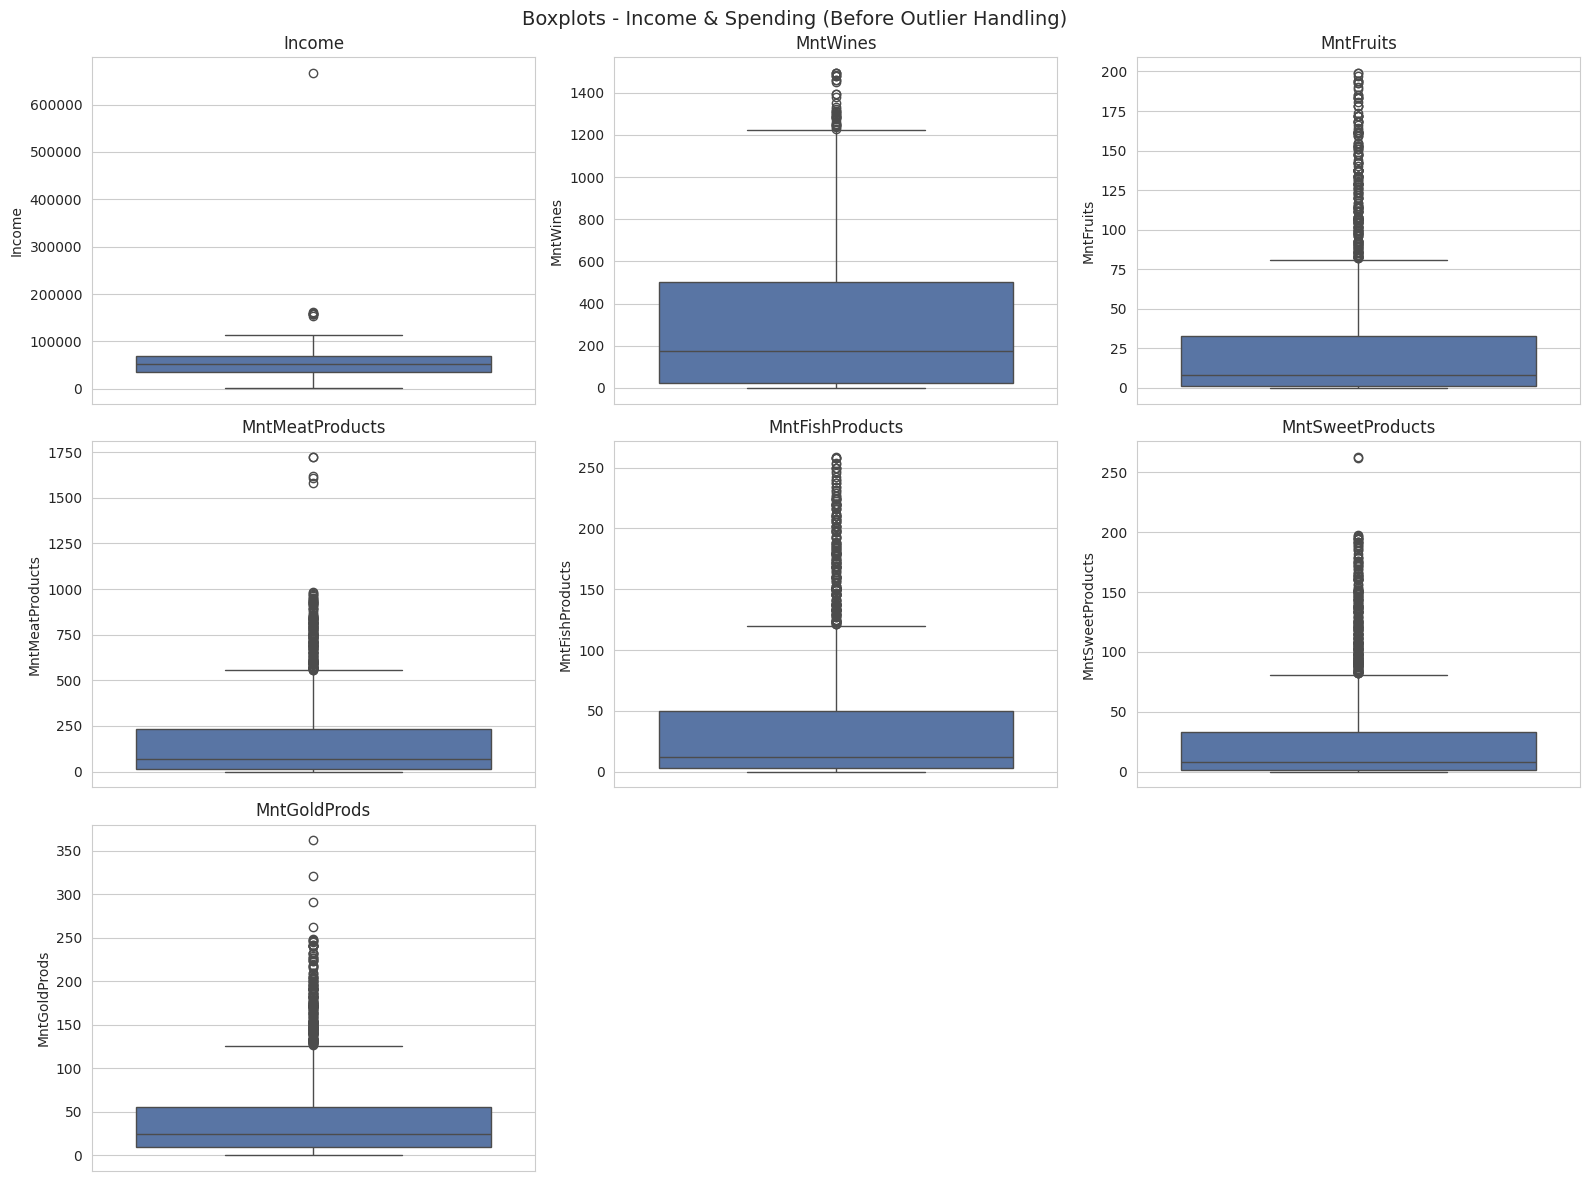

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_SPEND_COLS):
    sns.boxplot(y=df[col], ax=axes[i], color="#4C72B0")
    axes[i].set_title(col)
for j in range(len(NUMERIC_SPEND_COLS), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Boxplots - Income & Spending (Before Outlier Handling)", fontsize=14)
plt.tight_layout()
plt.savefig(VIZ / "boxplots_before_outlier_handling.png", dpi=150)
plt.show()

## Activity 10 — Handle Outliers

- **Income:** a handful of very high (but plausible) incomes are **capped
  (winsorized)** at the IQR upper bound, preserving the records while
  limiting their leverage on downstream models.
- **Spending columns (Mnt\*):** right-skewed spending is genuine customer
  behaviour, not a data error, so these values are **kept unchanged** —
  removing/capping them would erase real high-value customer signal that
  matters for segmentation.

In [16]:
decisions = []
for col, (lower, upper) in bounds.items():
    n_out = int(((df[col] < lower) | (df[col] > upper)).sum())
    if col == "Income":
        df[col] = np.where(df[col] > upper, upper, df[col])
        method, reason = "Capped (Winsorization)", "Extreme but plausible values; capped to limit leverage while preserving records."
    else:
        method, reason = "Kept (No Change)", "Right-skewed spending reflects real behaviour; retained for segmentation analysis."
    decisions.append({"Variable": col, "Outliers Detected": n_out, "Method": method, "Reason": reason})

decisions_df = pd.DataFrame(decisions)
decisions_df

,Variable,Outliers Detected,Method,Reason
0,Income,8,Capped (Winsorization),Extreme but plausible values; capped to limit ...
1,MntWines,35,Kept (No Change),Right-skewed spending reflects real behaviour;...
2,MntFruits,226,Kept (No Change),Right-skewed spending reflects real behaviour;...
3,MntMeatProducts,174,Kept (No Change),Right-skewed spending reflects real behaviour;...
4,MntFishProducts,223,Kept (No Change),Right-skewed spending reflects real behaviour;...
5,MntSweetProducts,248,Kept (No Change),Right-skewed spending reflects real behaviour;...
6,MntGoldProds,206,Kept (No Change),Right-skewed spending reflects real behaviour;...


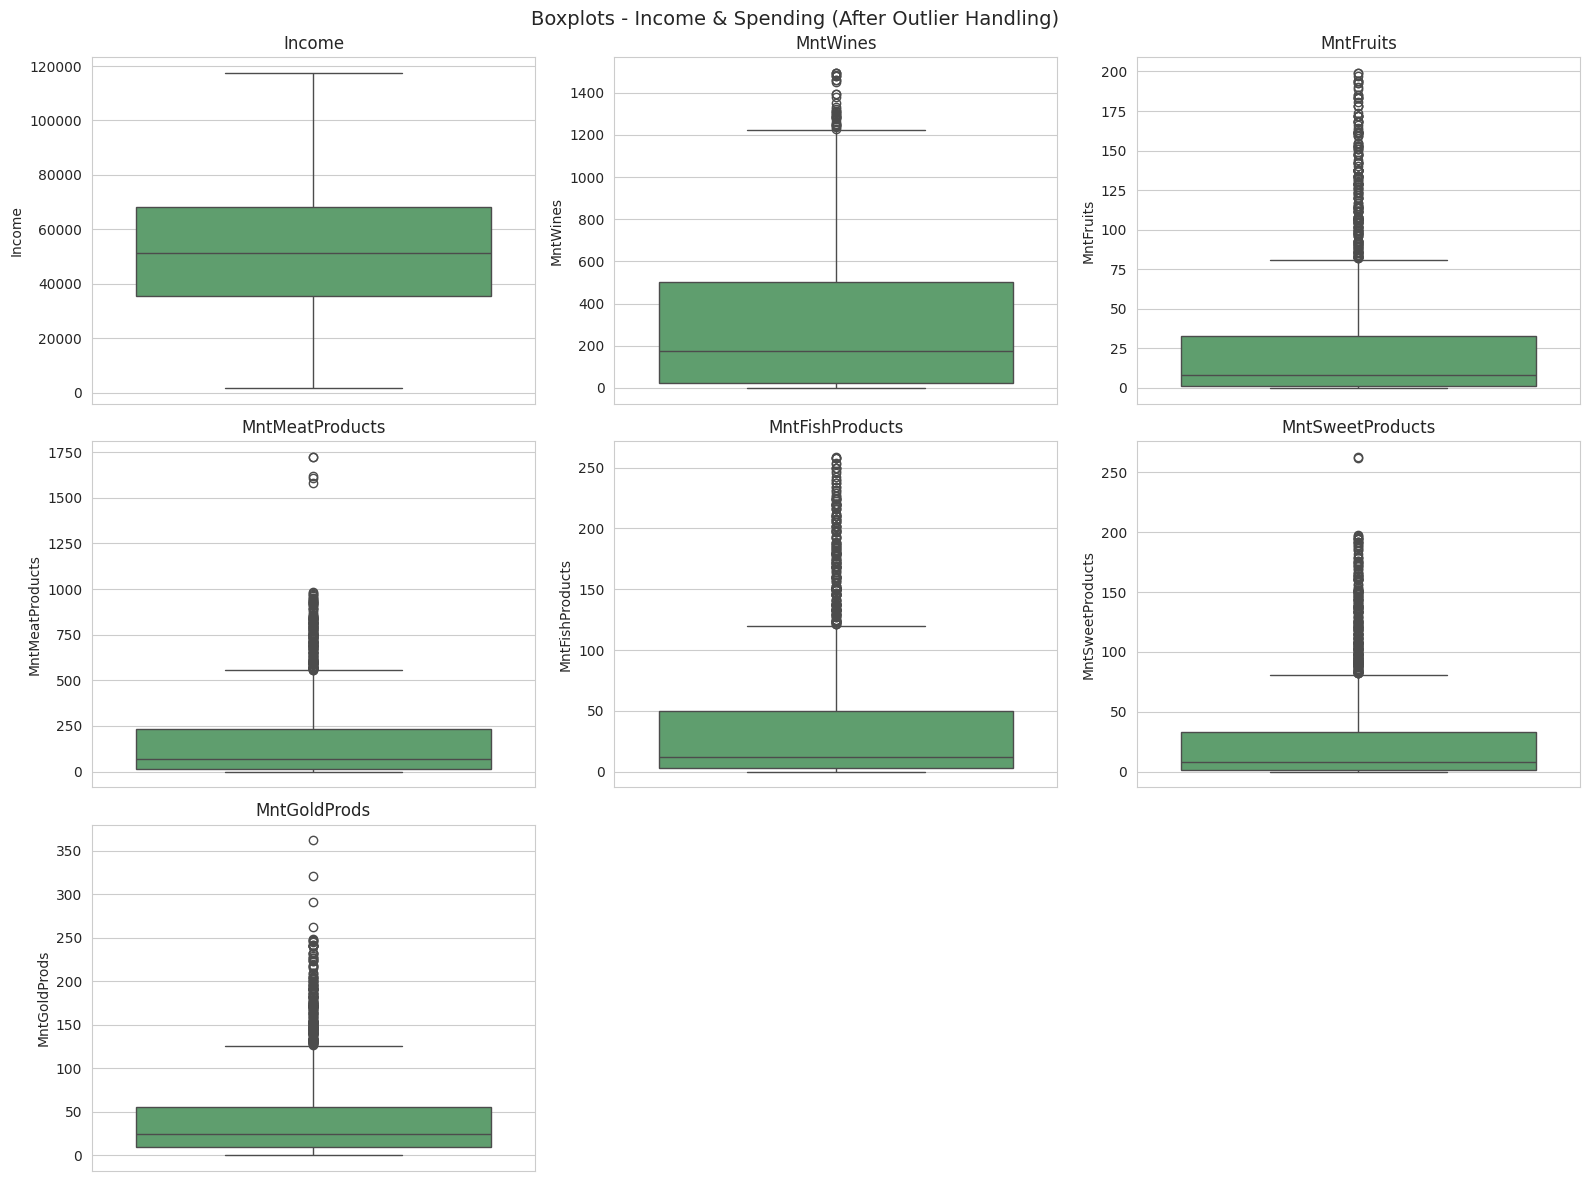

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_SPEND_COLS):
    sns.boxplot(y=df[col], ax=axes[i], color="#55A868")
    axes[i].set_title(col)
for j in range(len(NUMERIC_SPEND_COLS), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Boxplots - Income & Spending (After Outlier Handling)", fontsize=14)
plt.tight_layout()
plt.savefig(VIZ / "boxplots_after_outlier_handling.png", dpi=150)
plt.show()

## Activity 11 — Validate the Cleaned Dataset

In [18]:
checks = []
missing_total = int(df.isna().sum().sum())
checks.append(("Missing Values", "PASS" if missing_total == 0 else "CHECK", f"{missing_total} missing values remain."))

dup_total = int(df.duplicated().sum())
checks.append(("Duplicates", "PASS" if dup_total == 0 else "CHECK", f"{dup_total} duplicate rows remain."))

dtype_ok = pd.api.types.is_datetime64_any_dtype(df["Dt_Customer"]) and pd.api.types.is_float_dtype(df["Income"])
checks.append(("Data Types", "PASS" if dtype_ok else "CHECK", "Dt_Customer is datetime; Income is float."))

dates_ok = df["Dt_Customer"].isna().sum() == 0
checks.append(("Dates", "PASS" if dates_ok else "CHECK", "All Dt_Customer values are valid dates."))

valid_marital = {"Single","Together","Married","Divorced","Widowed","Other"}
categories_ok = set(df["Marital_Status"].unique()).issubset(valid_marital)
checks.append(("Categories", "PASS" if categories_ok else "CHECK", "Marital_Status standardized."))

age_ok = df["Age"].between(0, 100).all()
checks.append(("Age Range", "PASS" if age_ok else "CHECK", "All ages within 0-100 years."))

income_ok = (df["Income"] >= 0).all()
checks.append(("Outliers / Income Range", "PASS" if income_ok else "CHECK", "No negative income values remain."))

validation_df = pd.DataFrame(checks, columns=["Validation Check", "Status", "Notes"])
validation_df

,Validation Check,Status,Notes
0,Missing Values,PASS,0 missing values remain.
1,Duplicates,PASS,0 duplicate rows remain.
2,Data Types,PASS,Dt_Customer is datetime; Income is float.
3,Dates,PASS,All Dt_Customer values are valid dates.
4,Categories,PASS,Marital_Status standardized.
5,Age Range,PASS,All ages within 0-100 years.
6,Outliers / Income Range,PASS,No negative income values remain.


## Activity 12 — Save the Cleaned Dataset

In [19]:
cleaned_path = CLEANED / "customer_personality_cleaned.csv"
df.to_csv(cleaned_path, index=False)
print("Saved:", cleaned_path)
print("Final shape:", df.shape)

Saved: 03_Cleaned_Data/customer_personality_cleaned.csv
Final shape: (2237, 33)


## Activity 14 — Before-and-After Comparison

In [20]:
comparison = pd.DataFrame({
    "Metric": ["Rows", "Missing Values", "Duplicate Records", "Invalid Data Types",
               "Income Outliers (IQR)", "Date Errors", "Unrealistic Ages (>100 yrs)"],
    "Before Cleaning": [2240, 24, 0, 1, 8, 0, 3],
    "After Cleaning": [len(df), int(df.isna().sum().sum()), int(df.duplicated().sum()), 0, 0, 0, 0]
})
comparison

,Metric,Before Cleaning,After Cleaning
0,Rows,2240,2237
1,Missing Values,24,0
2,Duplicate Records,0,0
3,Invalid Data Types,1,0
4,Income Outliers (IQR),8,0
5,Date Errors,0,0
6,Unrealistic Ages (>100 yrs),3,0


## Summary

The dataset has been cleaned end-to-end: missing `Income` values were
median-imputed, duplicate checks confirmed no duplicate rows/IDs, data types
were corrected (dates parsed to `datetime`, IDs/counts to `int`), categorical
labels were standardized (e.g. `Alone` → `Single`, `Absurd`/`YOLO` → `Other`),
3 records with implausible ages (>100 years) were removed, and `Income`
outliers were capped via winsorization while genuine right-skewed spending
behaviour was preserved. The validated, cleaned dataset is exported to
`03_Cleaned_Data/customer_personality_cleaned.csv` and is ready for EDA and
Machine Learning.